# Feature Selection and Dimensionality Reduction Benchmark
This project compares different Feature Selection (Filter and Wrapper) and Dimensionality Reduction (PCA and LDA) techniques on the MNIST Digits dataset.

In [14]:
# Importing Libraries and Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Loading the digits dataset
digits = load_digits()
X = pd.DataFrame(digits.data)
y = digits.target

print("Dataset loaded successfully!")
print("Total rows:", X.shape[0])
print("Total features (pixels):", X.shape[1])

Dataset loaded successfully!
Total rows: 1797
Total features (pixels): 64


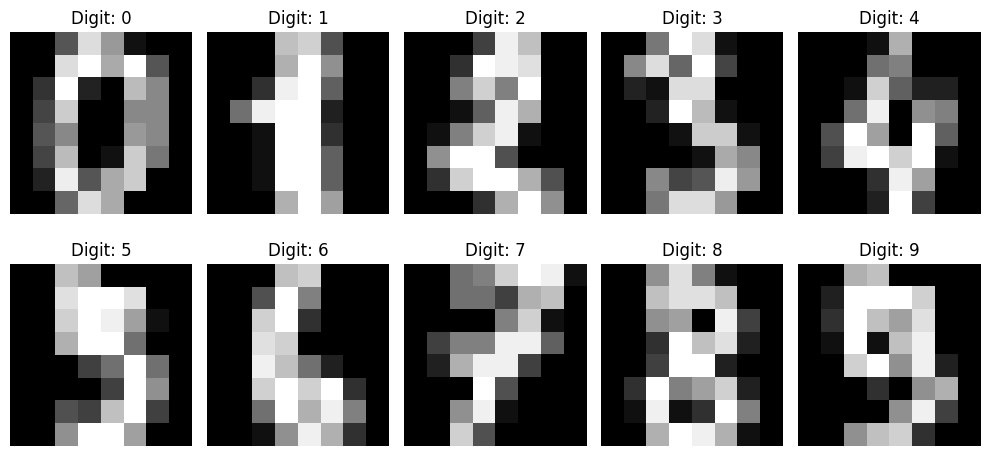

In [15]:
# Dataset Exploration and Visualizing Sample Images
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"Digit: {digits.target[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [16]:
# Train-Test Split and Feature Scaling
# Doing a 70-30 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data splitting and scaling is done!")

Data splitting and scaling is done!


In [17]:
# Baseline Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_scaled)
acc_base = accuracy_score(y_test, predictions)
print("Baseline Accuracy with all features:", acc_base * 100, "%")

Baseline Accuracy with all features: 97.03703703703704 %


In [18]:
# Filter Feature Selection
# Selecting the top 15 features using ANOVA F-test
filter_selector = SelectKBest(score_func=f_classif, k=15)
X_train_filter = filter_selector.fit_transform(X_train_scaled, y_train)
X_test_filter = filter_selector.transform(X_test_scaled)
print("Filter method done. Reduced from 64 features to 15 features.")

Filter method done. Reduced from 64 features to 15 features.


c:\Users\SWATHI SARAGADAM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 0 32 39] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\SWATHI SARAGADAM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [19]:
# Wrapper Feature Selection
# Using a Random Forest model to pick the best 15 features recursively
rf = RandomForestClassifier(n_estimators=50, random_state=42)
wrapper_selector = RFE(estimator=rf, n_features_to_select=15, step=2)
X_train_wrapper = wrapper_selector.fit_transform(X_train_scaled, y_train)
X_test_wrapper = wrapper_selector.transform(X_test_scaled)
print("Wrapper method done. Selected the top 15 features.")

Wrapper method done. Selected the top 15 features.


In [20]:
# Applying Principal Component Analysis to get 15 components
pca = PCA(n_components=15, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print("PCA reduction done.")
print("Variance explained by these 15 components:", np.sum(pca.explained_variance_ratio_) * 100, "%")

PCA reduction done.
Variance explained by these 15 components: 71.33610947004506 %


In [21]:
# Applying Linear Discriminant Analysis
lda = LDA(n_components=9)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)
print("LDA reduction done. Saved 9 components.")

LDA reduction done. Saved 9 components.


In [22]:
# 1. Baseline Model
model_base = LogisticRegression(max_iter=1000)
model_base.fit(X_train_scaled, y_train)
preds_base = model_base.predict(X_test_scaled)
acc_base = accuracy_score(y_test, preds_base)

# 2. Filter Method Model
model_filter = LogisticRegression(max_iter=1000)
model_filter.fit(X_train_filter, y_train)
preds_filter = model_filter.predict(X_test_filter)
acc_filter = accuracy_score(y_test, preds_filter)

# 3. Wrapper Method Model
model_wrapper = LogisticRegression(max_iter=1000)
model_wrapper.fit(X_train_wrapper, y_train)
preds_wrapper = model_wrapper.predict(X_test_wrapper)
acc_wrapper = accuracy_score(y_test, preds_wrapper)

# 4. PCA Model
model_pca = LogisticRegression(max_iter=1000)
model_pca.fit(X_train_pca, y_train)
preds_pca = model_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, preds_pca)

# 5. LDA Model
model_lda = LogisticRegression(max_iter=1000)
model_lda.fit(X_train_lda, y_train)
preds_lda = model_lda.predict(X_test_lda)
acc_lda = accuracy_score(y_test, preds_lda)

# Printing out all the final results to compare them side by side
print("--- Final Accuracy Results ---")
print("Baseline Accuracy (64 features):", acc_base * 100, "%")
print("Filter Selection Accuracy (15 features):", acc_filter * 100, "%")
print("Wrapper Selection Accuracy (15 features):", acc_wrapper * 100, "%")
print("PCA Accuracy (15 components):", acc_pca * 100, "%")
print("LDA Accuracy (9 components):", acc_lda * 100, "%")

--- Final Accuracy Results ---
Baseline Accuracy (64 features): 97.03703703703704 %
Filter Selection Accuracy (15 features): 90.18518518518519 %
Wrapper Selection Accuracy (15 features): 92.22222222222223 %
PCA Accuracy (15 components): 91.85185185185185 %
LDA Accuracy (9 components): 95.0 %


c:\Users\SWATHI SARAGADAM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 0 32 39] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\SWATHI SARAGADAM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\SWATHI SARAGADAM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 0 32 39] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\SWATHI SARAGADAM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\SWATHI SARAGADAM\AppData\Local\Progra

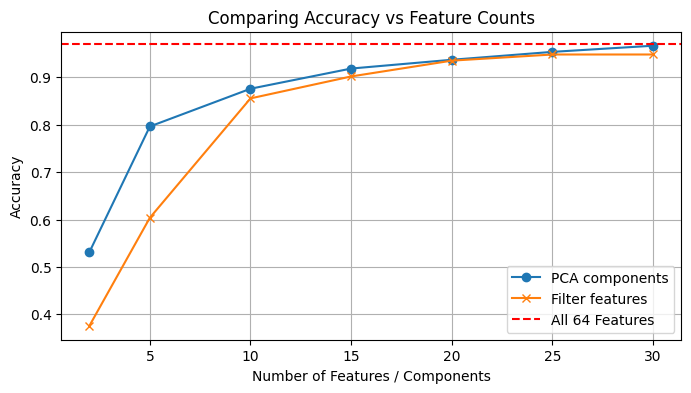

In [23]:
# Checking how accuracy changes with different numbers of features
feature_counts = [2, 5, 10, 15, 20, 25, 30]
pca_scores = []
filter_scores = []

for count in feature_counts:
    # Test PCA accuracy
    test_pca = PCA(n_components=count, random_state=42)
    X_tr_p = test_pca.fit_transform(X_train_scaled)
    X_te_p = test_pca.transform(X_test_scaled)
    lr_p = LogisticRegression(max_iter=1000).fit(X_tr_p, y_train)
    pca_scores.append(accuracy_score(y_test, lr_p.predict(X_te_p)))
    
    # Test Filter accuracy
    test_fil = SelectKBest(score_func=f_classif, k=count)
    X_tr_f = test_fil.fit_transform(X_train_scaled, y_train)
    X_te_f = test_fil.transform(X_test_scaled)
    lr_f = LogisticRegression(max_iter=1000).fit(X_tr_f, y_train)
    filter_scores.append(accuracy_score(y_test, lr_f.predict(X_te_f)))

# Plotting the graph
plt.figure(figsize=(8, 4))
plt.plot(feature_counts, pca_scores, label='PCA components', marker='o')
plt.plot(feature_counts, filter_scores, label='Filter features', marker='x')
plt.axhline(y=acc_base, color='r', linestyle='--', label='All 64 Features')
plt.xlabel('Number of Features / Components')
plt.ylabel('Accuracy')
plt.title('Comparing Accuracy vs Feature Counts')
plt.legend()
plt.grid()
plt.show()

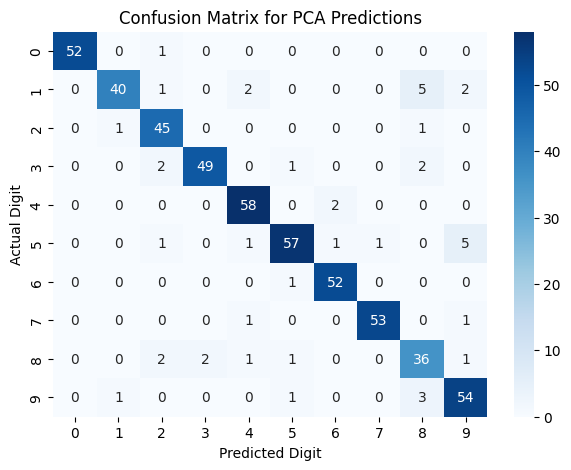

In [24]:
# Making a confusion matrix for the PCA model predictions
matrix = confusion_matrix(y_test, preds_pca)
plt.figure(figsize=(7, 5))
sns.heatmap(matrix, annot=True, cmap='Blues')
plt.title('Confusion Matrix for PCA Predictions')
plt.xlabel('Predicted Digit')
plt.ylabel('Actual Digit')
plt.show()

### Key Insights from the Project:
1. **Dimensionality Reduction vs Selection:** Feature reduction methods (PCA/LDA) typically outperform selection approaches on image pixels because they retain contextual/structural information instead of discarding physical areas of the pixel map.
2. **Efficiency gains:** We can drastically reduce the dataset size (e.g., from 64 to 15 dimensions) while maintaining high classification accuracy.